In [ ]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
#from scipy.optimize import minimize
#from noisyopt import minimizeCompass
from skopt import gp_minimize

relpath = os.path.dirname(os.path.abspath(''))
cob_date_str = '20251231'
ptfs = ['SP500_LongAll','SP500_Hedged']
measures= [0.05, 0.01]
output_path_part = 'C:\\Temp'
figpath = 'C:\\dev\\MLCopula\\document\\figures'

market_and_wghts =[]
for ptf_name in ptfs:
    ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\{ptf_name}.csv')
    ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

    market = mkt.Market(name=ptf_name, cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=7, interval='1d', cache_path=output_path_part)
    market.load_history()
    market_and_wghts.append((market,ptf_wghts))
    
cob, res_c, res_s =[], [], []
for i in range(75):
    new_cob_date = datetime.strptime(cob_date_str, '%Y%m%d').date() - timedelta(days=30*i)
    
    def error_func(x):
        error = 0.0
        for (market,ptf_wghts) in market_and_wghts:
            returns = market.get_logreturns(cob_date_str=new_cob_date.strftime('%Y%m%d'), sub_period_years=1)

            copula = js.MixCopulaNumTest(returns, [1.0]*len(ptf_names), weights=x)
            port_sim = v.VarSim(returns, market.spot, copula, np.array(ptf_wghts), method='midpoint')
            port_sim.calculate_pnls(10000)

            copula_hist = js.HistSimulation(returns, [1.0]*len(ptf_names))
            port_sim_hist = v.VarSim(returns, market.spot, copula_hist, np.array(ptf_wghts), method='midpoint')
            port_sim_hist.calculate_pnls(10000)

            for measure in measures:
                port_var = -round(port_sim.get_quantile(measure),2)
                port_var_hist = -round(port_sim_hist.get_quantile(measure),2)
                error_per_measure = abs(port_var - port_var_hist)
                error = error + error_per_measure

            
        print(f'-----> total error: {error}')
        return error
    
    #res = minimize(error_func, [0.0, 0.99], bounds= ,method='Nelder-Mead')
    #res = minimizeCompass(error_func, bounds=((0.0,1.0), (0.0,1.0)), x0=[0.9, 0.1], deltatol=0.1, paired=False)
    res = gp_minimize(error_func, [(0.0,1.0), (0.0,1.0)])

    cob.append(new_cob_date)
    res_c.append(list(res.x)[0])
    res_s.append(list(res.x)[1])


res_dict = {'COB': cob, 'CauchyWeight': res_c, 'CauchySkew':res_s}
res_full = pd.DataFrame(data=res_dict)
res_full.set_index('COB', inplace=True); res_full.sort_index(inplace=True)
res_full.to_csv(f'{output_path_part}\\OptimalCopula.csv')
res_full.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'OptimalCopula')
plt.savefig(f'{figpath}\\OptimalCopula.png', bbox_inches="tight")
plt.show()

In [ ]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
#from scipy.optimize import minimize
#from noisyopt import minimizeCompass
from skopt import gp_minimize

relpath = os.path.dirname(os.path.abspath(''))
cob_date_str = '20251231'

ptfs = ['SP500_LongAll','SP500_Hedged']
measures= [0.25, 0.1, 0.01, 0.005]

output_path_part = 'C:\\Temp'
figpath = 'C:\\dev\\MLCopula\\document\\figures'

dict_avg_var = {}
for ptf in ptfs:
    for measure in measures:
        measure_str = str(1000 - int(measure*1000)) 
        dfvar = pd.read_csv(f'{output_path_part}\\{ptf}-var_{measure_str}.csv')
        dfvar_hist = dfvar['VaR - Empirical marginals (midpoint) - Historical simulation']
        var_key = f"{ptf}-{measure_str}"
        dict_avg_var[var_key]= sum(dfvar_hist)/len(dfvar_hist)

market_and_wghts =[]
for ptf_name in ptfs:
    ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\{ptf_name}.csv')
    ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

    market = mkt.Market(name=ptf_name, cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=7, interval='1d', cache_path=output_path_part)
    market.load_history()
    market_and_wghts.append((market,ptf_wghts,ptf_name))
    
cob, res_c, res_s, res_fun =[], [], [], []
prev_x = [0.0]
for i in range(75):
    new_cob_date = datetime.strptime(cob_date_str, '%Y%m%d').date() - timedelta(days=30*i)
    
    def error_func(x):
        error = 0.0
        for (market,ptf_wghts,ptf_name) in market_and_wghts:
            returns = market.get_logreturns(cob_date_str=new_cob_date.strftime('%Y%m%d'), sub_period_years=1)

            copula = js.MixCopulaNumTest(returns, [1.0]*len(ptf_names), weights=[x[0], 0.95])
            port_sim = v.VarSim(returns, market.spot, copula, np.array(ptf_wghts), method='midpoint')
            port_sim.calculate_pnls(10000)

            copula_hist = js.HistSimulation(returns, [1.0]*len(ptf_names))
            port_sim_hist = v.VarSim(returns, market.spot, copula_hist, np.array(ptf_wghts), method='midpoint')
            port_sim_hist.calculate_pnls(10000)

            for measure in measures:
                measure_str = str(1000 - int(measure*1000)) 
                avg_var=dict_avg_var[f"{ptf_name}-{measure_str}"]
                port_var = -round(port_sim.get_quantile(measure),2)
                port_var_hist = -round(port_sim_hist.get_quantile(measure),2)
                error_per_measure = abs(port_var - port_var_hist)/avg_var
                error = error + error_per_measure

            
        print(f'-----> total error: {error}')
        return error
    
    #res = minimize(error_func, [0.0, 0.99], bounds= ,method='Nelder-Mead')
    #res = minimizeCompass(error_func, bounds=((0.0,1.0), (0.0,1.0)), x0=[0.9, 0.1], deltatol=0.1, paired=False)
    res = gp_minimize(error_func, [(0.0,1.0)], n_calls=40, x0=prev_x)

    cob.append(new_cob_date)
    res_c.append(list(res.x)[0])
    prev_x = list(res.x)
    res_s.append(0.95)
    res_fun.append(res.fun)


res_dict = {'COB': cob, 'CauchyWeight': res_c, 'CauchySkew':res_s, 'Error': res_fun}
res_full = pd.DataFrame(data=res_dict)
res_full.set_index('COB', inplace=True); res_full.sort_index(inplace=True)
res_full.to_csv(f'{output_path_part}\\OptimalCopulaGCS.csv')
res_full.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'OptimalCopulaGCS')
plt.savefig(f'{figpath}\\OptimalCopulaGCS.png', bbox_inches="tight")
plt.show()

Market stats 20251231-1Y, non nones count: 120032, needs 120032
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4840000, needs 4840000
=> min:0.004032258064516129, max:0.9999
Simulation stats, non nones count: 4801280, needs 4801280
Market stats 20251231-1Y, non nones count: 120032, needs 120032
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4840000, needs 4840000
=> min:0.004032258064516129, max:0.9999
Simulation stats, non nones count: 4801280, needs 4801280
-----> total error: 3.2969757974762928
Market stats 20251231-1Y, non nones count: 120032, needs 120032
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.004032258064516129, max:0.9999
Simulation stats, non nones count: 4801280, needs 4801280
Market stats 20251231-1Y, non nones count: 120032, needs 120032
=> min:0.0001, max:0.9999
Simulation stats, non nones count: 4839516, needs 4839516
=> min:0.004032258064516129, max:0.9999
Simulation stats, non nones count: 

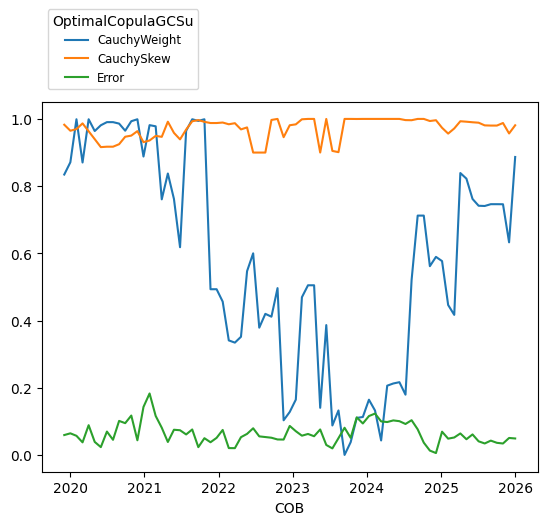

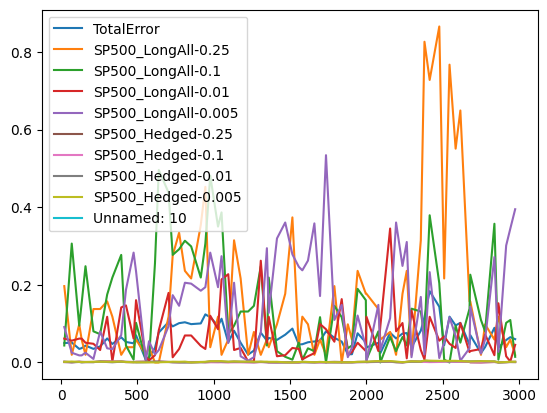

In [12]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
#from scipy.optimize import minimize
#from noisyopt import minimizeCompass
from skopt import gp_minimize

run_name = "OptimalCopulaGCSu"

relpath = os.path.dirname(os.path.abspath(''))
cob_date_str = '20251231'

ptfs = ['SP500_LongAll','SP500_Hedged']
measures= [0.25, 0.1, 0.01, 0.005]
store_errors = True

output_path_part = 'C:\\Temp'
figpath = 'C:\\dev\\MLCopula\\document\\figures'

dict_avg_var = {}

if store_errors: 
    with open(f'{output_path_part}\\Errors{run_name}.csv', 'w') as the_file:
        the_file.write('Date,TotalError,')
        for ptf in ptfs:
            for measure in measures:
                the_file.write(f'{ptf}-{str(measure)},')
        the_file.write('\n')     


for ptf in ptfs:
    for measure in measures:
        measure_str = str(1000 - int(measure*1000)) 
        dfvar = pd.read_csv(f'{output_path_part}\\{ptf}-var_{measure_str}.csv')
        dfvar_hist = dfvar['VaR - Empirical marginals (midpoint) - Historical simulation']
        var_key = f"{ptf}-{measure_str}"
        dict_avg_var[var_key]= sum(dfvar_hist)/len(dfvar_hist)

market_and_wghts =[]
for ptf_name in ptfs:
    ptf_df = pd.read_csv(f'{relpath}\\data\\portfolios\\{ptf_name}.csv')
    ptf_names, ptf_wghts = list(ptf_df['Symbol']), list(ptf_df['Weight'])

    market = mkt.Market(name=ptf_name, cob_date_str=cob_date_str, ticker_list=ptf_names, period_years=7, interval='1d', cache_path=output_path_part)
    market.load_history()
    market_and_wghts.append((market,ptf_wghts,ptf_name))
    
cob, res_c, res_s, res_fun =[], [], [], []
prev_x = [0.001, 0.999]

for i in range(75):
    new_cob_date = datetime.strptime(cob_date_str, '%Y%m%d').date() - timedelta(days=30*i)
    
    def error_func(x):
        error = []
        for (market,ptf_wghts,ptf_name) in market_and_wghts:
            returns = market.get_logreturns(cob_date_str=new_cob_date.strftime('%Y%m%d'), sub_period_years=1)

            copula = js.MixCopulaNumTest(returns, [1.0]*len(ptf_names), weights=[x[0], x[1]])
            port_sim = v.VarSim(returns, market.spot, copula, np.array(ptf_wghts), method='midpoint')
            port_sim.calculate_pnls(10000)

            copula_hist = js.HistSimulation(returns, [1.0]*len(ptf_names))
            port_sim_hist = v.VarSim(returns, market.spot, copula_hist, np.array(ptf_wghts), method='midpoint')
            port_sim_hist.calculate_pnls(10000)

            for measure in measures:
                measure_str = str(1000 - int(measure*1000)) 
                avg_var=dict_avg_var[f"{ptf_name}-{measure_str}"]
                port_var = -round(port_sim.get_quantile(measure),2)
                port_var_hist = -round(port_sim_hist.get_quantile(measure),2)
                error_per_measure = abs(port_var - port_var_hist)/avg_var
                error.append(error_per_measure)

             
        if store_errors: 
            with open(f'{output_path_part}\\Errors{run_name}.csv', 'a') as the_file:
                temp = [new_cob_date, sum(error)/(len(market_and_wghts)*len(measures))]
                temp.extend(error)
                the_file.write(', '.join(map(str,temp)) + '\n')


        print(f'-----> total error: {sum(error)}')
        return sum(error)/(len(market_and_wghts)*len(measures))
    
    #res = minimize(error_func, [0.0, 0.99], bounds= ,method='Nelder-Mead')
    #res = minimizeCompass(error_func, bounds=((0.0,1.0), (0.0,1.0)), x0=[0.9, 0.1], deltatol=0.1, paired=False)
    res = gp_minimize(error_func, [(0.001, 0.999), (0.9, 1.0)], n_calls=40, x0=prev_x)

    cob.append(new_cob_date)
    res_c.append(list(res.x)[0])
    prev_x = list(res.x)
    res_s.append(list(res.x)[1])
    res_fun.append(res.fun)


res_dict = {'COB': cob, 'CauchyWeight': res_c, 'CauchySkew':res_s, 'Error': res_fun}
res_full = pd.DataFrame(data=res_dict)
res_full.set_index('COB', inplace=True); res_full.sort_index(inplace=True)
res_full.to_csv(f'{output_path_part}\\{run_name}.csv')
res_full.plot().legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{run_name}')
plt.savefig(f'{figpath}\\{run_name}.png', bbox_inches="tight")
plt.show()


if store_errors: 
    errors_df = pd.read_csv(f'{output_path_part}\\Errors{run_name}.csv')
    filt_errors_df = errors_df.loc[errors_df.groupby('Date').TotalError.idxmin()]
    filt_errors_df.plot()#.legend(bbox_to_anchor=(0., 1.02, 1., .102), fontsize='small').set_title(f'{run_name}')
    plt.savefig(f'{figpath}\\error{run_name}.png', bbox_inches="tight")
    plt.show()